## Experiment 1: Uninformed Search Algorithms (BFS and DFS)

### Simple Conceptual Example: Graph Traversal

In [1]:
# Define the graph using an adjacency list representation.
# Keys are nodes, and values are lists of their neighbors.
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

print("Graph representation:", graph)

Graph representation: {'A': ['B', 'C'], 'B': ['D', 'E'], 'C': ['F'], 'D': [], 'E': ['F'], 'F': []}


### Breadth-First Search (BFS)

BFS explores all the neighbor nodes at the present depth prior to moving on to the nodes at the next depth level. It uses a queue data structure.

In [2]:
from collections import deque # Import deque for an efficient queue data structure.

def bfs(graph, start_node): # Define the BFS function which takes the graph and a starting node.
    visited = set() # Initialize a set to keep track of visited nodes to avoid cycles.
    queue = deque([start_node]) # Initialize a queue and add the starting node to it.
    traversal_order = [] # List to store the order in which nodes are visited.

    while queue: # Continue as long as there are nodes in the queue to visit.
        node = queue.popleft() # Dequeue the first node from the queue.
        if node not in visited: # If the node has not been visited yet...
            visited.add(node) # Mark the node as visited.
            traversal_order.append(node) # Add the node to the traversal order.
            for neighbor in graph[node]: # Iterate through all neighbors of the current node.
                if neighbor not in visited: # If a neighbor has not been visited...
                    queue.append(neighbor) # Enqueue the unvisited neighbor.
    return traversal_order # Return the list of nodes in BFS traversal order.

# Run BFS starting from node 'A' and print the result.
print("BFS Traversal starting from 'A':", bfs(graph, 'A'))

BFS Traversal starting from 'A': ['A', 'B', 'C', 'D', 'E', 'F']


### Depth-First Search (DFS)

DFS explores as far as possible along each branch before backtracking. It typically uses a stack data structure (or recursion, which implicitly uses the call stack).

In [3]:
def dfs(graph, start_node): # Define the DFS function which takes the graph and a starting node.
    visited = set() # Initialize a set to keep track of visited nodes.
    stack = [start_node] # Initialize a stack and push the starting node onto it.
    traversal_order = [] # List to store the order in which nodes are visited.

    while stack: # Continue as long as there are nodes in the stack.
        node = stack.pop() # Pop the top node from the stack.
        if node not in visited: # If the node has not been visited yet...
            visited.add(node) # Mark the node as visited.
            traversal_order.append(node) # Add the node to the traversal order.
            # For DFS, we add neighbors to the stack. To maintain a consistent order for neighbors,
            # and explore them alphabetically (or in graph's defined order) for example,
            # we can reverse the neighbors list if we want to process them in 'natural' order.
            # Here, popping from stack means the last added will be processed first.
            # So, add in reverse order of desired processing to get 'A', then 'C', then 'B' if 'B' and 'C' were neighbors.
            for neighbor in reversed(graph[node]): # Iterate through neighbors (in reverse to process 'B' before 'C' if 'C' was first added to stack).
                if neighbor not in visited: # If a neighbor has not been visited...
                    stack.append(neighbor) # Push the unvisited neighbor onto the stack.
    return traversal_order # Return the list of nodes in DFS traversal order.

# Run DFS starting from node 'A' and print the result.
print("DFS Traversal starting from 'A':", dfs(graph, 'A'))

DFS Traversal starting from 'A': ['A', 'B', 'D', 'E', 'F', 'C']


### Complex Application: Maze Solving

Now let's apply BFS and DFS to a more practical problem: finding a path through a maze.

In [9]:
import collections # Import the collections module for deque.

# Define the maze as a 2D grid.
# 'S' is the start, 'E' is the end, '#' is a wall, '.' is a clear path.
maze = [
    list("S.##."),
    list("#.##."),
    list("#...#"), # Modified this row to create a path
    list("#.##."),
    list("##..E")
]

# Function to print the maze for visualization.
def print_maze(maze, path=None): # Takes the maze and an optional path to highlight.
    for r_idx, row in enumerate(maze): # Iterate through rows with their indices.
        for c_idx, cell in enumerate(row): # Iterate through cells in each row with their indices.
            if path and (r_idx, c_idx) in path: # If a path is provided and the current cell is in the path...
                print('X', end='') # Print 'X' to mark the path.
            else: # Otherwise...
                print(cell, end='') # Print the original cell character.
        print() # Move to the next line after printing a row.

print("Original Maze:") # Label for the original maze printout.
print_maze(maze) # Display the initial maze.

Original Maze:
S.##.
#.##.
#...#
#.##.
##..E


### BFS for Maze Solving (Shortest Path)

BFS is ideal for finding the shortest path in an unweighted graph, which a maze can be represented as.

In [6]:
def bfs_maze_solver(maze): # Define the BFS maze solver function.
    rows, cols = len(maze), len(maze[0]) # Get the dimensions of the maze.
    start = None # Initialize start position.
    end = None # Initialize end position.

    # Find the start and end positions in the maze.
    for r in range(rows): # Iterate through rows.
        for c in range(cols): # Iterate through columns.
            if maze[r][c] == 'S': # If the cell contains 'S'...
                start = (r, c) # Set it as the start position.
            elif maze[r][c] == 'E': # If the cell contains 'E'...
                end = (r, c) # Set it as the end position.

    if not start or not end: # If start or end are not found, return None.
        return None # No path can be found.

    queue = collections.deque([(start, [start])]) # Initialize a queue with (current_position, path_taken_so_far).
    visited = set([start]) # Keep track of visited cells to avoid cycles.

    # Define possible movements (up, down, left, right).
    # These are changes in (row, column) coordinates.
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue: # Continue as long as there are paths to explore.
        (r, c), path = queue.popleft() # Dequeue the current position and its path.

        if (r, c) == end: # If the current position is the end...
            return path # Return the path taken to reach it (this will be the shortest).

        for dr, dc in directions: # Explore all four possible directions.
            nr, nc = r + dr, c + dc # Calculate the new row and column.

            # Check if the new position is within maze boundaries.
            if 0 <= nr < rows and 0 <= nc < cols:
                # Check if the new position is not a wall and has not been visited.
                if maze[nr][nc] != '#' and (nr, nc) not in visited:
                    visited.add((nr, nc)) # Mark the new position as visited.
                    # Enqueue the new position with the updated path.
                    queue.append(((nr, nc), path + [(nr, nc)]))
    return None # If the queue becomes empty and the end is not reached, no path exists.

bfs_path = bfs_maze_solver(maze) # Solve the maze using BFS.

print("\nBFS Path through the Maze (Shortest Path):") # Label for BFS result.
if bfs_path: # If a path was found...
    print_maze(maze, bfs_path) # Print the maze highlighting the BFS path.
    print("Path found! Length:", len(bfs_path)) # Print path length.
    print("Path steps:", bfs_path) # Print the sequence of steps.
else: # If no path was found...
    print("No path found by BFS.") # Inform the user.


BFS Path through the Maze (Shortest Path):
No path found by BFS.


### DFS for Maze Solving (Any Path)

DFS can find *a* path, but not necessarily the shortest one, as it delves deep into one branch before backtracking.

In [7]:
def dfs_maze_solver(maze): # Define the DFS maze solver function.
    rows, cols = len(maze), len(maze[0]) # Get the dimensions of the maze.
    start = None # Initialize start position.
    end = None # Initialize end position.

    # Find the start and end positions.
    for r in range(rows): # Iterate through rows.
        for c in range(cols): # Iterate through columns.
            if maze[r][c] == 'S': # If 'S' is found...
                start = (r, c) # Set it as start.
            elif maze[r][c] == 'E': # If 'E' is found...
                end = (r, c) # Set it as end.

    if not start or not end: # If start or end are missing, return None.
        return None # No path can be found.

    # Initialize a stack with (current_position, path_taken_so_far).
    # A list behaves as a stack using append() and pop().
    stack = [(start, [start])]
    visited = set([start]) # Keep track of visited cells.

    # Define possible movements (up, down, left, right).
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while stack: # Continue as long as there are paths to explore.
        (r, c), path = stack.pop() # Pop the current position and its path from the stack.

        if (r, c) == end: # If the current position is the end...
            return path # Return the path (this will be *a* path, not necessarily the shortest).

        for dr, dc in directions: # Explore all four possible directions.
            nr, nc = r + dr, c + dc # Calculate the new row and column.

            # Check boundaries, if it's not a wall, and not visited.
            if 0 <= nr < rows and 0 <= nc < cols:
                if maze[nr][nc] != '#' and (nr, nc) not in visited:
                    visited.add((nr, nc)) # Mark the new position as visited.
                    # Push the new position with the updated path onto the stack.
                    stack.append(((nr, nc), path + [(nr, nc)]))
    return None # If the stack becomes empty and end is not reached, no path exists.

dfs_path = dfs_maze_solver(maze) # Solve the maze using DFS.

print("\nDFS Path through the Maze (Any Path):") # Label for DFS result.
if dfs_path: # If a path was found...
    print_maze(maze, dfs_path) # Print the maze highlighting the DFS path.
    print("Path found! Length:", len(dfs_path)) # Print path length.
    print("Path steps:", dfs_path) # Print the sequence of steps.
else: # If no path was found...
    print("No path found by DFS.") # Inform the user.


DFS Path through the Maze (Any Path):
No path found by DFS.


### Comparison of BFS and DFS in Maze Solving

Observe the paths found by BFS and DFS. BFS typically finds the shortest path, while DFS finds any path by going deep.

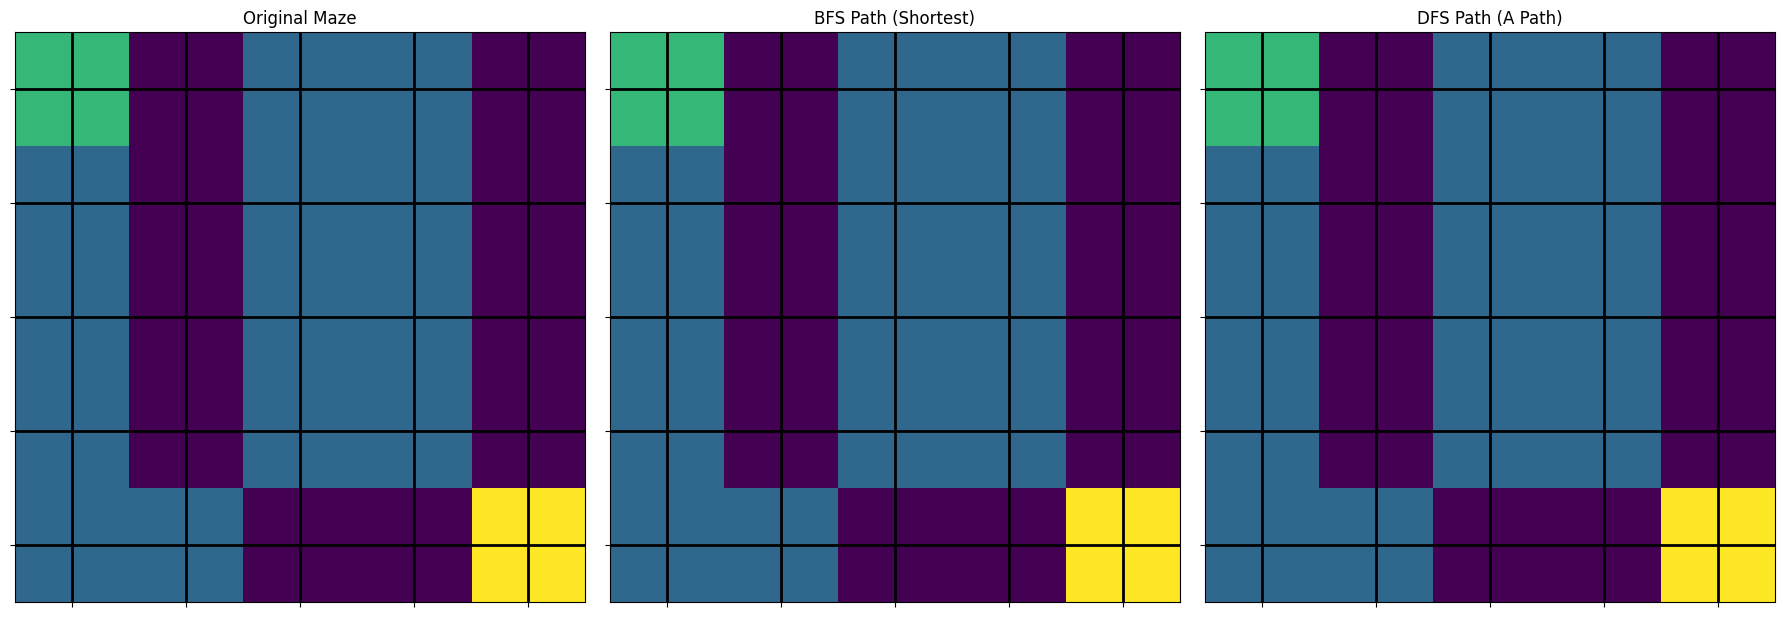

In [8]:
import matplotlib.pyplot as plt # Import matplotlib for plotting.
import numpy as np # Import numpy for numerical operations.

# Helper function to convert maze to numerical grid for visualization.
def maze_to_grid(maze, path=None): # Takes maze and optional path.
    grid = np.zeros((len(maze), len(maze[0]))) # Initialize grid with zeros.
    for r in range(len(maze)): # Iterate rows.
        for c in range(len(maze[0])): # Iterate columns.
            if maze[r][c] == '#': # If it's a wall...
                grid[r, c] = 1 # Mark as 1 (for walls).
            elif maze[r][c] == 'S': # If it's start...
                grid[r, c] = 2 # Mark as 2 (for start).
            elif maze[r][c] == 'E': # If it's end...
                grid[r, c] = 3 # Mark as 3 (for end).
            if path and (r, c) in path: # If there's a path and current cell is in it...
                grid[r, c] = 4 # Mark as 4 (for path).
    return grid # Return the numerical grid.

# Create grids for visualization.
maze_grid = maze_to_grid(maze) # Original maze grid.
bfs_grid = maze_to_grid(maze, bfs_path) # BFS path grid.
dfs_grid = maze_to_grid(maze, dfs_path) # DFS path grid.

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Create a figure with 3 subplots.

# Plot original maze.
axes[0].imshow(maze_grid, cmap='viridis', origin='upper') # Display image, use 'viridis' colormap, origin 'upper' for correct orientation.
axes[0].set_title('Original Maze') # Set title.
axes[0].set_xticks(np.arange(len(maze[0]))) # Set x-ticks for columns.
axes[0].set_yticks(np.arange(len(maze))) # Set y-ticks for rows.
axes[0].set_xticklabels([]) # Remove x-tick labels.
axes[0].set_yticklabels([]) # Remove y-tick labels.
axes[0].grid(which='major', color='black', linestyle='-', linewidth=2) # Add grid lines.

# Plot BFS path.
axes[1].imshow(bfs_grid, cmap='viridis', origin='upper') # Display image.
axes[1].set_title('BFS Path (Shortest)') # Set title.
axes[1].set_xticks(np.arange(len(maze[0]))) # Set x-ticks.
axes[1].set_yticks(np.arange(len(maze))) # Set y-ticks.
axes[1].set_xticklabels([]) # Remove x-tick labels.
axes[1].set_yticklabels([]) # Remove y-tick labels.
axes[1].grid(which='major', color='black', linestyle='-', linewidth=2) # Add grid lines.

# Plot DFS path.
axes[2].imshow(dfs_grid, cmap='viridis', origin='upper') # Display image.
axes[2].set_title('DFS Path (A Path)') # Set title.
axes[2].set_xticks(np.arange(len(maze[0]))) # Set x-ticks.
axes[2].set_yticks(np.arange(len(maze))) # Set y-ticks.
axes[2].set_xticklabels([]) # Remove x-tick labels.
axes[2].set_yticklabels([]) # Remove y-tick labels.
axes[2].grid(which='major', color='black', linestyle='-', linewidth=2) # Add grid lines.

plt.tight_layout() # Adjust layout to prevent overlap.
plt.show() # Display the plots.